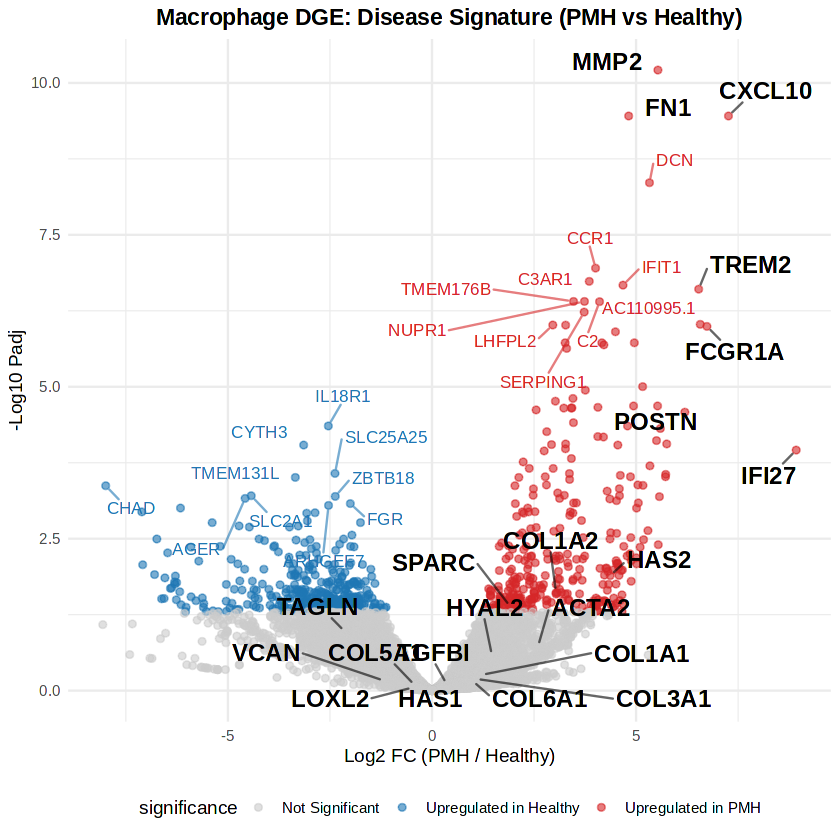

In [ ]:
# 1. Load required libraries
suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(ggrepel)
})

# ------------------------------------------------------------------------------
# 2. USER CONFIGURATION
# ------------------------------------------------------------------------------
# Read the DESeq2 output
res_df <- read.csv("/home/johan/output/skin_pmh_harmony_sctransform2/subset_cluster/macrophage/dge_pseudobulk/deseq2_PMH_vs_Healthy_ALL_COMBINED_macrophage.csv")

# Define the groups being compared (for titles and legends)
group1 <- "PMH"      # Adjusted to match your file name (PMH vs Healthy)
group2 <- "Healthy"
title_prefix <- "Macrophage DGE: Disease Signature"

# Define your custom colors for the dots and text
color_up_g1 <- "#D62728" # Red  (Upregulated in Group 1)
color_up_g2 <- "#1F77B4" # Blue (Upregulated in Group 2)
color_ns    <- "grey80"  # Grey (Not Significant)

# SPECIFY THE NARRATIVE GENES YOU WANT TO SPOTLIGHT IN BLACK
genes_to_label_black <- c("MUC1", "CXCL10", "IFI27", "HAS1", "FN1", "MMP2", "TREM2", "FCGR1A", "HAS2", "HAS1", "HAS3", "VCAN", "FN1", "CEMIP", "HYAL1", "HYAL2", "CTGF", "TGFBI", "COL1A1", "COL1A2", "COL3A1", "COL5A1", "COL6A1", "SPARC", "POSTN", "ACTA2", "TAGLN", "LOX", "LOXL2")

# ------------------------------------------------------------------------------
# 3. DATA PREPARATION & TOP 10 SELECTION
# ------------------------------------------------------------------------------
# Create significance column
res_df <- res_df %>%
  mutate(
    significance = case_when(
      padj < 0.05 & log2FoldChange > 1 ~ paste("Upregulated in", group1),
      padj < 0.05 & log2FoldChange < -1 ~ paste("Upregulated in", group2),
      TRUE ~ "Not Significant"
    )
  )

# Map the colors to the significance categories for the dots
my_colors <- c(color_up_g1, color_up_g2, color_ns)
names(my_colors) <- c(paste("Upregulated in", group1), 
                      paste("Upregulated in", group2), 
                      "Not Significant")

# --- EXTRACT LABELS ---

# 1. Extract the manually chosen black narrative genes
label_black_df <- res_df %>% 
  filter(gene %in% genes_to_label_black) %>%
  mutate(label_color = "black", label_face = "bold", label_size = 5.0)

# 2. Extract Top 10 for Group 1 (Red) based on lowest padj
# We exclude the black-labeled genes so they don't get labeled twice
top10_g1 <- res_df %>%
  filter(significance == paste("Upregulated in", group1)) %>%
  filter(!(gene %in% genes_to_label_black)) %>% 
  arrange(padj, desc(log2FoldChange)) %>%
  head(10) %>%
  mutate(label_color = color_up_g1, label_face = "plain", label_size = 3.5)

# 3. Extract Top 10 for Group 2 (Blue) based on lowest padj
top10_g2 <- res_df %>%
  filter(significance == paste("Upregulated in", group2)) %>%
  filter(!(gene %in% genes_to_label_black)) %>%
  arrange(padj, log2FoldChange) %>%
  head(10) %>%
  mutate(label_color = color_up_g2, label_face = "plain", label_size = 3.5)

# 4. Combine all labels into one dataframe so ggrepel avoids overlapping them
combined_labels <- bind_rows(label_black_df, top10_g1, top10_g2)

# ------------------------------------------------------------------------------
# 4. GENERATE VOLCANO PLOT
# ------------------------------------------------------------------------------
# Create the base plot with the dots
p_volcano <- ggplot(res_df, aes(x = log2FoldChange, y = -log10(padj))) +
  geom_point(aes(color = significance), alpha = 0.6, size = 1.5) +
  scale_color_manual(values = my_colors) +
  theme_minimal() +
  labs(
    title = paste(title_prefix, sprintf("(%s vs %s)", group1, group2)), 
    x = sprintf("Log2 FC (%s / %s)", group1, group2), 
    y = "-Log10 Padj"
  ) +
  theme(
    legend.position = "bottom", 
    plot.title = element_text(hjust = 0.5, face = "bold")
  )

# Add the combined text labels
if(nrow(combined_labels) > 0) {
  p_volcano <- p_volcano + 
    geom_text_repel(
      data = combined_labels, 
      aes(label = gene), 
      # Apply the exact color, fontface, and size we defined in the dataframe
      color = combined_labels$label_color,
      fontface = combined_labels$label_face,
      size = combined_labels$label_size,
      box.padding = 0.6,
      point.padding = 0.3,
      max.overlaps = Inf,
      segment.color = combined_labels$label_color, # Line matches the text color
      segment.alpha = 0.6
    )
}

# ------------------------------------------------------------------------------
# 5. DISPLAY PLOT IN NOTEBOOK
# ------------------------------------------------------------------------------
print(p_volcano)

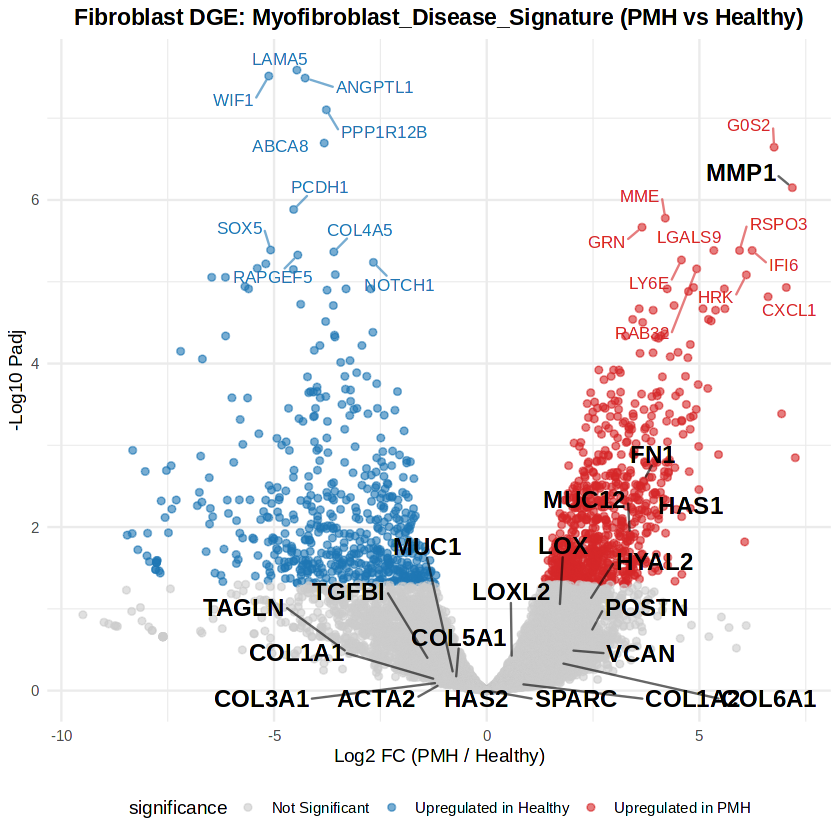

In [ ]:
# 1. Load required libraries
suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(ggrepel)
})

# ------------------------------------------------------------------------------
# 2. USER CONFIGURATION
# ------------------------------------------------------------------------------
# Read the DESeq2 output
res_df <- read.csv("/home/johan/output/skin_pmh_harmony_sctransform2/subset_cluster/fibroblast/dge_pseudobulk/deseq2_PMH_vs_Healthy_fibroblast_Myofibroblast_Disease_Signature.csv")

# Define the groups being compared (for titles and legends)
group1 <- "PMH"      # Adjusted to match your file name (PMH vs Healthy)
group2 <- "Healthy"
title_prefix <- "Fibroblast DGE: Myofibroblast_Disease_Signature"

# Define your custom colors for the dots and text
color_up_g1 <- "#D62728" # Red  (Upregulated in Group 1)
color_up_g2 <- "#1F77B4" # Blue (Upregulated in Group 2)
color_ns    <- "grey80"  # Grey (Not Significant)

# SPECIFY THE NARRATIVE GENES YOU WANT TO SPOTLIGHT IN BLACK
genes_to_label_black <- c("MUC1", "HAS1", "HAS2", "MMP1", "MUC12", "HAS2", "HAS1", "HAS3", "VCAN", "FN1", "CEMIP", "HYAL1", "HYAL2", "CTGF", "TGFBI", "COL1A1", "COL1A2", "COL3A1", "COL5A1", "COL6A1", "SPARC", "POSTN", "ACTA2", "TAGLN", "LOX", "LOXL2")

# ------------------------------------------------------------------------------
# 3. DATA PREPARATION & TOP 10 SELECTION
# ------------------------------------------------------------------------------
# Create significance column
res_df <- res_df %>%
  mutate(
    significance = case_when(
      padj < 0.05 & log2FoldChange > 1 ~ paste("Upregulated in", group1),
      padj < 0.05 & log2FoldChange < -1 ~ paste("Upregulated in", group2),
      TRUE ~ "Not Significant"
    )
  )

# Map the colors to the significance categories for the dots
my_colors <- c(color_up_g1, color_up_g2, color_ns)
names(my_colors) <- c(paste("Upregulated in", group1), 
                      paste("Upregulated in", group2), 
                      "Not Significant")

# --- EXTRACT LABELS ---

# 1. Extract the manually chosen black narrative genes
label_black_df <- res_df %>% 
  filter(gene %in% genes_to_label_black) %>%
  mutate(label_color = "black", label_face = "bold", label_size = 5.0)

# 2. Extract Top 10 for Group 1 (Red) based on lowest padj
# We exclude the black-labeled genes so they don't get labeled twice
top10_g1 <- res_df %>%
  filter(significance == paste("Upregulated in", group1)) %>%
  filter(!(gene %in% genes_to_label_black)) %>% 
  arrange(padj, desc(log2FoldChange)) %>%
  head(10) %>%
  mutate(label_color = color_up_g1, label_face = "plain", label_size = 3.5)

# 3. Extract Top 10 for Group 2 (Blue) based on lowest padj
top10_g2 <- res_df %>%
  filter(significance == paste("Upregulated in", group2)) %>%
  filter(!(gene %in% genes_to_label_black)) %>%
  arrange(padj, log2FoldChange) %>%
  head(10) %>%
  mutate(label_color = color_up_g2, label_face = "plain", label_size = 3.5)

# 4. Combine all labels into one dataframe so ggrepel avoids overlapping them
combined_labels <- bind_rows(label_black_df, top10_g1, top10_g2)

# ------------------------------------------------------------------------------
# 4. GENERATE VOLCANO PLOT
# ------------------------------------------------------------------------------
# Create the base plot with the dots
p_volcano <- ggplot(res_df, aes(x = log2FoldChange, y = -log10(padj))) +
  geom_point(aes(color = significance), alpha = 0.6, size = 1.5) +
  scale_color_manual(values = my_colors) +
  theme_minimal() +
  labs(
    title = paste(title_prefix, sprintf("(%s vs %s)", group1, group2)), 
    x = sprintf("Log2 FC (%s / %s)", group1, group2), 
    y = "-Log10 Padj"
  ) +
  theme(
    legend.position = "bottom", 
    plot.title = element_text(hjust = 0.5, face = "bold")
  )

# Add the combined text labels
if(nrow(combined_labels) > 0) {
  p_volcano <- p_volcano + 
    geom_text_repel(
      data = combined_labels, 
      aes(label = gene), 
      # Apply the exact color, fontface, and size we defined in the dataframe
      color = combined_labels$label_color,
      fontface = combined_labels$label_face,
      size = combined_labels$label_size,
      box.padding = 0.6,
      point.padding = 0.3,
      max.overlaps = Inf,
      segment.color = combined_labels$label_color, # Line matches the text color
      segment.alpha = 0.6
    )
}

# ------------------------------------------------------------------------------
# 5. DISPLAY PLOT IN NOTEBOOK
# ------------------------------------------------------------------------------
print(p_volcano)

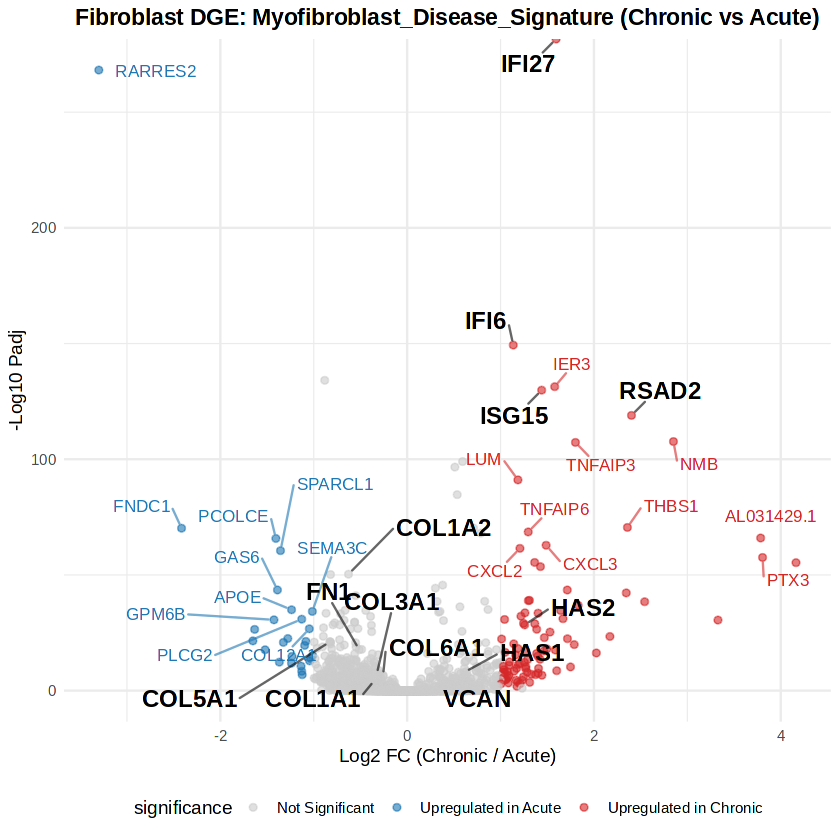

In [ ]:
# 1. Load required libraries
suppressPackageStartupMessages({
  library(ggplot2)
  library(dplyr)
  library(ggrepel)
})

# ------------------------------------------------------------------------------
# 2. USER CONFIGURATION
# ------------------------------------------------------------------------------
# Read the DESeq2 output
res_df <- read.csv("/home/johan/output/skin_pmh_harmony_sctransform2/subset_cluster/fibroblast/dge_pseudobulk/deseq2_Chronic_vs_Acute_fibroblast_Myofibroblast_Disease_Signature.csv")

# Define the groups being compared (for titles and legends)
group1 <- "Chronic"      # Adjusted to match your file name (PMH vs Healthy)
group2 <- "Acute"
title_prefix <- "Fibroblast DGE: Myofibroblast_Disease_Signature"

# Define your custom colors for the dots and text
color_up_g1 <- "#D62728" # Red  (Upregulated in Group 1)
color_up_g2 <- "#1F77B4" # Blue (Upregulated in Group 2)
color_ns    <- "grey80"  # Grey (Not Significant)

# SPECIFY THE NARRATIVE GENES YOU WANT TO SPOTLIGHT IN BLACK
genes_to_label_black <- c("IFI27", "IFI6", "ISG15", "RSAD2", "HAS2", "HAS1", "HAS3", "VCAN", "FN1", "CEMIP", "HYAL1", "HYAL2", "CTGF", "TGFBI", "COL1A1", "COL1A2", "COL3A1", "COL5A1", "COL6A1")

# ------------------------------------------------------------------------------
# 3. DATA PREPARATION & TOP 10 SELECTION
# ------------------------------------------------------------------------------
# Create significance column
res_df <- res_df %>%
  mutate(
    significance = case_when(
      padj < 0.05 & log2FoldChange > 1 ~ paste("Upregulated in", group1),
      padj < 0.05 & log2FoldChange < -1 ~ paste("Upregulated in", group2),
      TRUE ~ "Not Significant"
    )
  )

# Map the colors to the significance categories for the dots
my_colors <- c(color_up_g1, color_up_g2, color_ns)
names(my_colors) <- c(paste("Upregulated in", group1), 
                      paste("Upregulated in", group2), 
                      "Not Significant")

# --- EXTRACT LABELS ---

# 1. Extract the manually chosen black narrative genes
label_black_df <- res_df %>% 
  filter(gene %in% genes_to_label_black) %>%
  mutate(label_color = "black", label_face = "bold", label_size = 5.0)

# 2. Extract Top 10 for Group 1 (Red) based on lowest padj
# We exclude the black-labeled genes so they don't get labeled twice
top10_g1 <- res_df %>%
  filter(significance == paste("Upregulated in", group1)) %>%
  filter(!(gene %in% genes_to_label_black)) %>% 
  arrange(padj, desc(log2FoldChange)) %>%
  head(10) %>%
  mutate(label_color = color_up_g1, label_face = "plain", label_size = 3.5)

# 3. Extract Top 10 for Group 2 (Blue) based on lowest padj
top10_g2 <- res_df %>%
  filter(significance == paste("Upregulated in", group2)) %>%
  filter(!(gene %in% genes_to_label_black)) %>%
  arrange(padj, log2FoldChange) %>%
  head(10) %>%
  mutate(label_color = color_up_g2, label_face = "plain", label_size = 3.5)

# 4. Combine all labels into one dataframe so ggrepel avoids overlapping them
combined_labels <- bind_rows(label_black_df, top10_g1, top10_g2)

# ------------------------------------------------------------------------------
# 4. GENERATE VOLCANO PLOT
# ------------------------------------------------------------------------------
# Create the base plot with the dots
p_volcano <- ggplot(res_df, aes(x = log2FoldChange, y = -log10(padj))) +
  geom_point(aes(color = significance), alpha = 0.6, size = 1.5) +
  scale_color_manual(values = my_colors) +
  theme_minimal() +
  labs(
    title = paste(title_prefix, sprintf("(%s vs %s)", group1, group2)), 
    x = sprintf("Log2 FC (%s / %s)", group1, group2), 
    y = "-Log10 Padj"
  ) +
  theme(
    legend.position = "bottom", 
    plot.title = element_text(hjust = 0.5, face = "bold")
  )

# Add the combined text labels
if(nrow(combined_labels) > 0) {
  p_volcano <- p_volcano + 
    geom_text_repel(
      data = combined_labels, 
      aes(label = gene), 
      # Apply the exact color, fontface, and size we defined in the dataframe
      color = combined_labels$label_color,
      fontface = combined_labels$label_face,
      size = combined_labels$label_size,
      box.padding = 0.6,
      point.padding = 0.3,
      max.overlaps = Inf,
      segment.color = combined_labels$label_color, # Line matches the text color
      segment.alpha = 0.6
    )
}

# ------------------------------------------------------------------------------
# 5. DISPLAY PLOT IN NOTEBOOK
# ------------------------------------------------------------------------------
print(p_volcano)

In [ ]:
csv_path = '/home/johan/output/skin_pmh_harmony_sctransform2/subset_cluster/fibroblast/dge_pseudobulk/deseq2_PMH_vs_Healthy_fibroblast_Myofibroblast_Disease_Signature.csv'

df = pd.read_csv(csv_path)
df.head()

,gene,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,significance
0,LAMA5,15.879466,-4.462717,0.635333,-7.024216,2.152715e-12,2.578307e-08,Upregulated in Healthy
1,WIF1,6.394912,-5.123538,0.742229,-6.902906,5.094920e-12,3.051093e-08,Upregulated in Healthy
2,ANGPTL1,13.840135,-4.269622,0.624488,-6.837000,8.086871e-12,3.228548e-08,Upregulated in Healthy
3,PPP1R12B,20.991340,-3.770767,0.565723,-6.665393,2.639575e-11,7.903547e-08,Upregulated in Healthy
4,ABCA8,10.664661,-3.820761,0.588433,-6.493111,8.408186e-11,2.014097e-07,Upregulated in Healthy


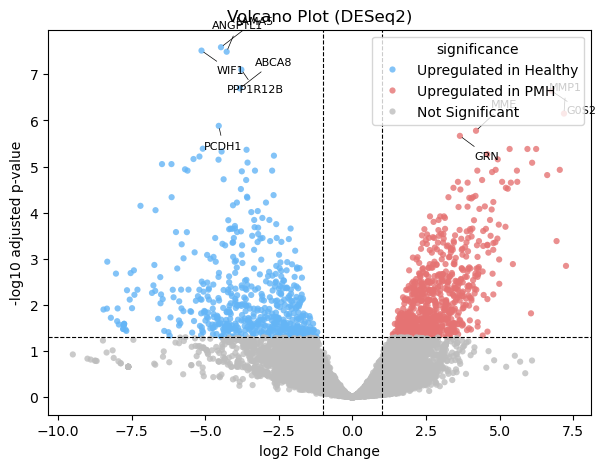

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# correct column name
df["-log10_padj"] = -np.log10(df["padj"].fillna(1))

palette = {
    "Upregulated in PMH": "#E57373",      # soft red
    "Upregulated in Healthy": "#64B5F6",  # soft blue
    "Not Significant": "#BDBDBD"          # grey
}

plt.figure(figsize=(7,5))

sns.scatterplot(
    data=df,
    x="log2FoldChange",
    y="-log10_padj",
    hue="significance",
    palette=palette,
    alpha=0.8,
    s=20,
    linewidth=0
)

# label top genes (safe subset only)
offsets = [(0.5, 0.5), (0.5, -0.5), (-0.5, 0.5), (-0.5, -0.5)]

for i, (_, row) in enumerate(top.iterrows()):
    dx, dy = offsets[i % len(offsets)]

    plt.annotate(
        row["gene"],
        xy=(row["log2FoldChange"], row["-log10_padj"]),
        xytext=(row["log2FoldChange"] + dx, row["-log10_padj"] + dy),
        fontsize=8,
        arrowprops=dict(arrowstyle="-", lw=0.5)
    )

plt.axhline(-np.log10(0.05), ls="--", c="black", lw=0.8)
plt.axvline(-1, ls="--", c="black", lw=0.8)
plt.axvline(1, ls="--", c="black", lw=0.8)

plt.title("Volcano Plot (DESeq2)")
plt.xlabel("log2 Fold Change")
plt.ylabel("-log10 adjusted p-value")

plt.show()